<a href="https://colab.research.google.com/github/sachinadk2011/handwritten-alphanumeric-recognition/blob/add%2Fmodel3/handwritten_recognition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/github/sachinadk2011/handwritten-alphanumeric-recognition/blob/main/handwritten_recognition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [34]:
from sklearn.model_selection import train_test_split
from matplotlib import pyplot as plt
import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense, Flatten, Dropout, Conv2D, MaxPooling2D, BatchNormalization, Activation
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping


In [13]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [51]:
import os
import random
import numpy as np

SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)
os.environ["TF_DETERMINISTIC_OPS"] = "1"

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

tf.config.experimental.enable_op_determinism()

In [52]:
# generators
train_ds  = keras.utils.image_dataset_from_directory(
    directory = "/content/drive/MyDrive/handwritten_english_character_and_digits/handwritten-english-characters-and-digits/combined_folder/train",
    labels="inferred",
    label_mode="int",
    batch_size=32,
    image_size=(128, 128),
    shuffle=True,
    seed=42,
)

validation_ds =  keras.utils.image_dataset_from_directory(
    directory = "/content/drive/MyDrive/handwritten_english_character_and_digits/handwritten-english-characters-and-digits/combined_folder/test",
    labels="inferred",
    label_mode="int",
    batch_size=32,
    image_size=(128, 128),
    shuffle=False,
)

Found 2728 files belonging to 62 classes.
Found 682 files belonging to 62 classes.


In [53]:
aug_ds = keras.utils.image_dataset_from_directory(
    directory = "/content/drive/MyDrive/handwritten_english_character_and_digits/augmented_images/augmented_images1",
    labels="inferred",
    label_mode="int",
    batch_size=64,
    image_size=(128, 128),
    shuffle=True,
    seed=42,
)

Found 13640 files belonging to 62 classes.


In [54]:
#normalize
def process(image, label):
    image = tf.cast(image/255., tf.float32)
    return image, label

In [55]:
train_ds = train_ds.map(process)
validation_ds = validation_ds.map(process)

In [56]:
aug_ds = aug_ds.map(process)

images, label = next(iter(aug_ds))
images.shape, label.shape

(TensorShape([64, 128, 128, 3]), TensorShape([64]))

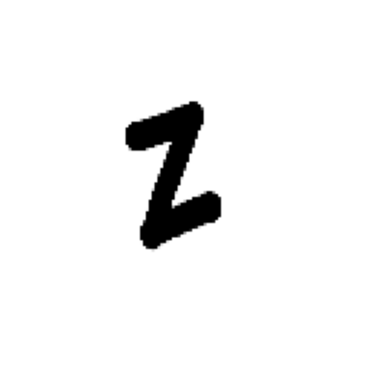

In [57]:
plt.imshow(images[2].numpy())
plt.axis('off')
plt.show()

In [58]:
images, labels = next(iter(train_ds))
images.shape, labels.shape

(TensorShape([32, 128, 128, 3]), TensorShape([32]))

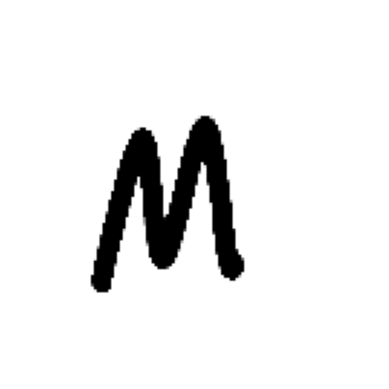

In [59]:
plt.imshow(images[2].numpy())
plt.axis('off')
plt.show()

In [60]:
def accuracy_vs_epochs(history):
  plt.plot(history.history['accuracy'], label='accuracy')
  plt.plot(history.history['val_accuracy'], label='val_accuracy')
  plt.xlabel('Epoch')
  plt.ylabel('Accuracy')
  plt.ylim(0, 1)
  plt.legend(loc='lower right')
  plt.show()

In [ ]:
#model 1
model1 = Sequential([
    Conv2D(32, (3,3), activation= 'relu', padding = "same", input_shape = (128, 128, 3)),

    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation= 'relu', padding = "same"),
    MaxPooling2D((2,2)),

    Conv2D(128, (3,3), activation= 'relu', padding = "same"),
    MaxPooling2D((2,2)),

    Conv2D(160, (3,3), activation= 'relu', padding = "same"),
    MaxPooling2D((2,2)),

    Flatten(),
    Dense(128, activation='relu'),

    Dense(62, activation='softmax')
])

model1.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model1.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 160)    │       184,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 160)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 10240)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,310,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 62)             │         7,998 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,596,574 (6.09 MB)

 Trainable params: 1,596,574 (6.09 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history1 = model1.fit(train_ds, epochs=10, validation_data=validation_ds)

Epoch 1/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 600s 7s/step - accuracy: 0.0561 - loss: 3.9252 - val_accuracy: 0.2038 - val_loss: 3.0700
Epoch 2/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 19s 222ms/step - accuracy: 0.3889 - loss: 2.3478 - val_accuracy: 0.5044 - val_loss: 1.7378
Epoch 3/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 22s 240ms/step - accuracy: 0.6653 - loss: 1.1730 - val_accuracy: 0.6466 - val_loss: 1.3165
Epoch 4/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 19s 222ms/step - accuracy: 0.7973 - loss: 0.6745 - val_accuracy: 0.6701 - val_loss: 1.3714
Epoch 5/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 19s 221ms/step - accuracy: 0.8688 - loss: 0.4282 - val_accuracy: 0.6965 - val_loss: 1.2973
Epoch 6/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 23s 246ms/step - accuracy: 0.9267 - loss: 0.2342 - val_accuracy: 0.7053 - val_loss: 1.4300
Epoch 7/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 20s 229ms/step - accuracy: 0.9468 - loss: 0.1694 - val_accuracy: 0.7229 - val_loss: 1.5713
Epoch 8/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 20s 224ms/step - accuracy: 0.9652 - loss: 0.1050 - val_accura

In [ ]:
history1_2 = model1.fit(aug_ds, epochs=10, validation_data=validation_ds)

Epoch 1/10
214/214 ━━━━━━━━━━━━━━━━━━━━ 91s 424ms/step - accuracy: 0.5529 - loss: 1.6739 - val_accuracy: 0.7859 - val_loss: 0.6683
Epoch 2/10
214/214 ━━━━━━━━━━━━━━━━━━━━ 88s 412ms/step - accuracy: 0.8106 - loss: 0.5952 - val_accuracy: 0.7977 - val_loss: 0.6925
Epoch 3/10
214/214 ━━━━━━━━━━━━━━━━━━━━ 88s 412ms/step - accuracy: 0.9003 - loss: 0.2913 - val_accuracy: 0.7786 - val_loss: 0.8629
Epoch 4/10
214/214 ━━━━━━━━━━━━━━━━━━━━ 88s 409ms/step - accuracy: 0.9431 - loss: 0.1613 - val_accuracy: 0.8094 - val_loss: 0.9424
Epoch 5/10
214/214 ━━━━━━━━━━━━━━━━━━━━ 88s 413ms/step - accuracy: 0.9574 - loss: 0.1165 - val_accuracy: 0.7903 - val_loss: 1.0004
Epoch 6/10
214/214 ━━━━━━━━━━━━━━━━━━━━ 87s 406ms/step - accuracy: 0.9672 - loss: 0.0927 - val_accuracy: 0.7845 - val_loss: 1.1160
Epoch 7/10
214/214 ━━━━━━━━━━━━━━━━━━━━ 88s 410ms/step - accuracy: 0.9737 - loss: 0.0763 - val_accuracy: 0.7977 - val_loss: 1.1513
Epoch 8/10
214/214 ━━━━━━━━━━━━━━━━━━━━ 142s 409ms/step - accuracy: 0.9743 - loss: 

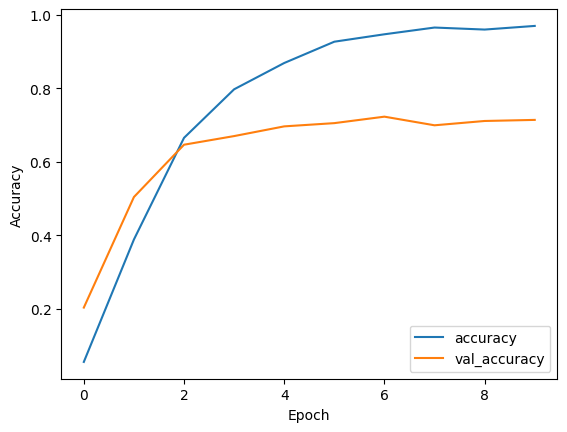

In [ ]:
accuracy_vs_epochs(history1)

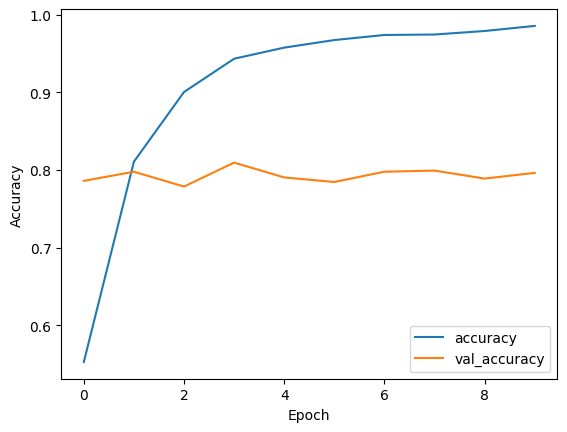

In [ ]:
accuracy_vs_epochs(history1_2)

In [ ]:
#model 2
model2 = Sequential([
    Conv2D(32, (3,3), activation= 'relu',  input_shape = (128, 128, 3)),

    MaxPooling2D(pool_size=(2,2), strides = (2,2)),

    Conv2D(64, (3,3), activation= 'relu', ),
    MaxPooling2D(pool_size=(2,2), strides = (2,2)),

    Conv2D(128, (3,3), activation= 'relu', ),
    MaxPooling2D(pool_size=(2,2), strides = (2,2)),

    Conv2D(160, (3,3), activation= 'relu'),
    MaxPooling2D(pool_size=(2,2), strides = (2,2)),

    Flatten(),
    Dense(64, activation='relu'),

    Dense(62, activation='softmax')
])

model2.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model2.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 12, 12, 160)    │       184,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 6, 6, 160)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 5760)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │       368,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 62)             │         4,030 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 650,462 (2.48 MB)

 Trainable params: 650,462 (2.48 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history2 = model2.fit(train_ds, epochs=10, validation_data=validation_ds)

Epoch 1/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 23s 236ms/step - accuracy: 0.0400 - loss: 4.0402 - val_accuracy: 0.1144 - val_loss: 3.7185
Epoch 2/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 29s 333ms/step - accuracy: 0.2698 - loss: 2.8526 - val_accuracy: 0.4677 - val_loss: 1.9595
Epoch 3/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 26s 299ms/step - accuracy: 0.5872 - loss: 1.4933 - val_accuracy: 0.6261 - val_loss: 1.3791
Epoch 4/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 30s 347ms/step - accuracy: 0.7328 - loss: 0.8973 - val_accuracy: 0.6760 - val_loss: 1.2661
Epoch 5/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 31s 230ms/step - accuracy: 0.8251 - loss: 0.5529 - val_accuracy: 0.7038 - val_loss: 1.1685
Epoch 6/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 21s 249ms/step - accuracy: 0.8809 - loss: 0.3795 - val_accuracy: 0.7302 - val_loss: 1.2324
Epoch 7/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 20s 234ms/step - accuracy: 0.9249 - loss: 0.2362 - val_accuracy: 0.7111 - val_loss: 1.4484
Epoch 8/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 21s 243ms/step - accuracy: 0.9432 - loss: 0.1754 - val_accu

In [ ]:
history21= model2.fit(aug_ds, epochs=10, validation_data=validation_ds)

Epoch 1/10
214/214 ━━━━━━━━━━━━━━━━━━━━ 87s 408ms/step - accuracy: 0.5176 - loss: 1.8069 - val_accuracy: 0.7757 - val_loss: 0.6616
Epoch 2/10
214/214 ━━━━━━━━━━━━━━━━━━━━ 87s 407ms/step - accuracy: 0.7498 - loss: 0.7817 - val_accuracy: 0.7889 - val_loss: 0.6129
Epoch 3/10
214/214 ━━━━━━━━━━━━━━━━━━━━ 88s 411ms/step - accuracy: 0.8499 - loss: 0.4546 - val_accuracy: 0.7962 - val_loss: 0.6615
Epoch 4/10
214/214 ━━━━━━━━━━━━━━━━━━━━ 88s 411ms/step - accuracy: 0.9017 - loss: 0.2832 - val_accuracy: 0.8211 - val_loss: 0.6674
Epoch 5/10
214/214 ━━━━━━━━━━━━━━━━━━━━ 87s 407ms/step - accuracy: 0.9295 - loss: 0.1955 - val_accuracy: 0.8182 - val_loss: 0.7311
Epoch 6/10
214/214 ━━━━━━━━━━━━━━━━━━━━ 86s 401ms/step - accuracy: 0.9469 - loss: 0.1468 - val_accuracy: 0.8065 - val_loss: 0.8624
Epoch 7/10
214/214 ━━━━━━━━━━━━━━━━━━━━ 88s 410ms/step - accuracy: 0.9605 - loss: 0.1135 - val_accuracy: 0.7962 - val_loss: 1.0557
Epoch 8/10
214/214 ━━━━━━━━━━━━━━━━━━━━ 87s 405ms/step - accuracy: 0.9618 - loss: 0

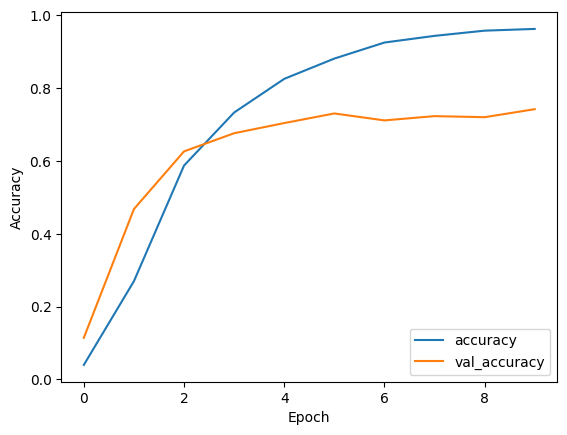

In [ ]:
accuracy_vs_epochs(history2)

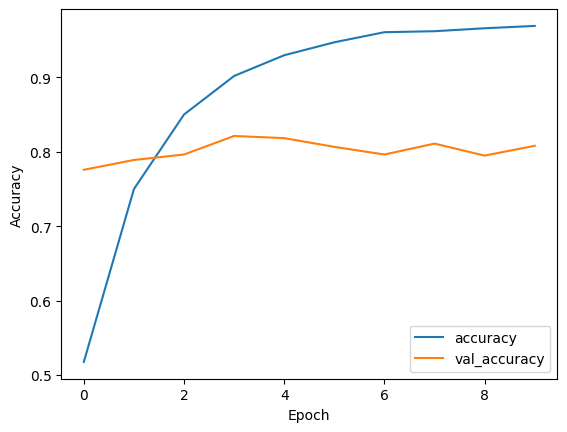

In [ ]:
accuracy_vs_epochs(history21)

## Overfitting and Data Augmentation

Our models were initially **overfitting**, which may have been partly due to the relatively **small training dataset of around 2,000 images**. With limited training data, a CNN can memorize the training examples instead of learning features that generalize well to unseen data.

To address this, we trained the models further using an **augmented dataset** containing around **13,000 images**. **Data augmentation** introduced different variations of the original images, such as small rotations, shifts, and zooms. This provides the model with more variation during training and encourages it to learn more robust features rather than relying on the exact appearance or position of the original images.

### Model 1

Model 1 initially achieved a best validation accuracy of approximately **72.29%** using the original training dataset. After continuing training with the augmented dataset, its best validation accuracy increased to **80.94%**.

However, the training accuracy continued to increase to around **98.53%**, while validation accuracy remained around **80%**. This indicates that the model still suffers from overfitting despite the additional augmented data.

### Model 2

Model 2 initially achieved a best validation accuracy of approximately **74.19%** using the original training dataset. After training further on the augmented dataset, its best validation accuracy increased to **82.11%**.

This shows that data augmentation significantly improved the model's ability to generalize to unseen images. However, the model still shows some overfitting because its training accuracy reached approximately **96.89%**, while its best validation accuracy was **82.11%**.

### Comparison

| Model | Original Data | Augmented Data |
|-------|---------------:|---------------:|
| Model 1 | 72.29% | 80.94% |
| Model 2 | 74.19% | **82.11%** |

The results show that **data augmentation significantly improved both models**. Model 2 currently performs better than Model 1, achieving a best validation accuracy of **82.11%**.

Although Model 1 has a larger dense layer (`Dense(128)`), the additional capacity did not provide a significant advantage. In this experiment, the simpler Model 2 with `Dense(64)` achieved better validation performance.

There is still a noticeable gap between training and validation accuracy, indicating that **overfitting remains a problem**. Therefore, the next step is to investigate **regularization techniques**, particularly **Dropout**, to determine whether reducing the model's ability to memorize the training data can improve validation performance.


In [61]:
# model 3
model3 = Sequential([
    Conv2D(32, (3,3), input_shape=(128,128,3)),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2,2), strides=(2,2)),

    Conv2D(64, (3,3)),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2,2), strides=(2,2)),

    Conv2D(128, (3,3)),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2,2), strides=(2,2)),

    Conv2D(160, (3,3)),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2,2), strides=(2,2)),

    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(62, activation='softmax')
])
model3.compile(optimizer=Adam(learning_rate=1e-4, clipnorm=1.0), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model3.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 126, 126, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_12 (Activation)      │ (None, 126, 126, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 61, 61, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_13 (Activation)      │ (None, 61, 61, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_14 (Activation)      │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 12, 12, 160)    │       184,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 12, 12, 160)    │           640 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_15 (Activation)      │ (None, 12, 12, 160)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 6, 6, 160)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 5760)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │       368,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 62)             │         4,030 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 651,998 (2.49 MB)

 Trainable params: 651,230 (2.48 MB)

 Non-trainable params: 768 (3.00 KB)

In [62]:
early_stop = EarlyStopping(
 monitor='val_loss', patience=10, restore_best_weights=True
)


In [63]:
history3 = model3.fit(train_ds, epochs=100, validation_data=validation_ds, callbacks=[early_stop])

Epoch 1/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 25s 252ms/step - accuracy: 0.0389 - loss: 4.1085 - val_accuracy: 0.0161 - val_loss: 4.1358
Epoch 2/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 22s 250ms/step - accuracy: 0.0649 - loss: 3.8863 - val_accuracy: 0.0161 - val_loss: 4.1880
Epoch 3/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 21s 248ms/step - accuracy: 0.1004 - loss: 3.6667 - val_accuracy: 0.0176 - val_loss: 4.1916
Epoch 4/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 20s 229ms/step - accuracy: 0.1510 - loss: 3.4703 - val_accuracy: 0.0205 - val_loss: 4.0574
Epoch 5/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 21s 242ms/step - accuracy: 0.1946 - loss: 3.2408 - val_accuracy: 0.0909 - val_loss: 3.8167
Epoch 6/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 22s 254ms/step - accuracy: 0.2449 - loss: 3.0452 - val_accuracy: 0.2273 - val_loss: 3.4122
Epoch 7/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 21s 250ms/step - accuracy: 0.2936 - loss: 2.7952 - val_accuracy: 0.3109 - val_loss: 3.0998
Epoch 8/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 20s 228ms/step - accuracy: 0.3457 - loss: 2.5885 - 

In [ ]:
history3_1 = model3.fit(aug_ds, epochs=100, validation_data=validation_ds, callbacks=[early_stop])

Epoch 1/100
214/214 ━━━━━━━━━━━━━━━━━━━━ 2603s 12s/step - accuracy: 0.2016 - loss: 3.3007 - val_accuracy: 0.5557 - val_loss: 1.6859
Epoch 2/100
214/214 ━━━━━━━━━━━━━━━━━━━━ 148s 414ms/step - accuracy: 0.2896 - loss: 2.7249 - val_accuracy: 0.6320 - val_loss: 1.3755
Epoch 3/100
214/214 ━━━━━━━━━━━━━━━━━━━━ 140s 407ms/step - accuracy: 0.3436 - loss: 2.4352 - val_accuracy: 0.7346 - val_loss: 1.0661
Epoch 4/100
214/214 ━━━━━━━━━━━━━━━━━━━━ 142s 405ms/step - accuracy: 0.3923 - loss: 2.2006 - val_accuracy: 0.7390 - val_loss: 1.0135
Epoch 5/100
214/214 ━━━━━━━━━━━━━━━━━━━━ 89s 413ms/step - accuracy: 0.4342 - loss: 2.0004 - val_accuracy: 0.7199 - val_loss: 1.0118
Epoch 6/100
214/214 ━━━━━━━━━━━━━━━━━━━━ 87s 407ms/step - accuracy: 0.4695 - loss: 1.8345 - val_accuracy: 0.7185 - val_loss: 0.9844
Epoch 7/100
214/214 ━━━━━━━━━━━━━━━━━━━━ 89s 413ms/step - accuracy: 0.5048 - loss: 1.7069 - val_accuracy: 0.6891 - val_loss: 1.0706
Epoch 8/100
214/214 ━━━━━━━━━━━━━━━━━━━━ 88s 411ms/step - accuracy: 0.537

In [1]:
import pickle

In [2]:
accuracy_vs_epochs(history3)

NameError: name 'accuracy_vs_epochs' is not defined